# COMPAS-2x Pastries: Data Trends and Analysis

## Setup

The heavy analysis and figure generation were already done by `scripts/analyze_compas_trends.py`. Here we load the generated figures and summary tables for presentation.

In [18]:
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import Image, display
except ImportError:
    Image = None
    display = None

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
ANALYSIS_DIR = ROOT / 'data_analysis'
FIG_DIR = ANALYSIS_DIR / 'figures'
TABLE_DIR = ANALYSIS_DIR / 'tables'

RING_LABELS = {
    'benzene': 'Benzene (Bn)',
    'pyridine': 'Pyridine (Pd)',
    'pyrazine': 'Pyrazine (Pz)',
    'pyrrole': 'Pyrrole (Py)',
    'furan': 'Furan (Fu)',
    'thiophene': 'Thiophene (Th)',
    'borole': 'Borole (Bl)',
    'borinine': 'Borazine (Bz)',
    '14diborinine': 'DiBorinine (DBn)',
    'dhdiborinine': 'Dhydrodiborinine (DhDBn)',
    'cyclobutadiene': 'Cyclobutadiene (Cbd)',
}

def show_image(filename, width=15):
    path = FIG_DIR / filename
    if Image is not None and display is not None:
        display(Image(filename=str(path), width=int(width * 80)))
        return
    image = plt.imread(path)
    height = width * image.shape[0] / image.shape[1]
    plt.figure(figsize=(width, height))
    plt.imshow(image)
    plt.axis('off')
    plt.close()

def show_table(filename, columns=None, n=20):
    table = pd.read_csv(TABLE_DIR / filename)
    if columns is not None:
        table = table[columns]
    return table.head(n)

## Dataset Overview

Here is a summarize the ring-type composition of the dataset. Benzene (Bn) appears in almost all molecules, while each non-benzene building block appears in roughly one third of molecules in this dataset.

In [19]:
ring_summary = pd.read_csv(TABLE_DIR / 'ring_type_summary.csv')
ring_summary = ring_summary.assign(ring_label=ring_summary['ring_type'].map(RING_LABELS))
ring_summary[['ring_label', 'total_ring_instances', 'molecules_with_ring', 'fraction_of_molecules', 'mean_count_when_present']]


,ring_label,total_ring_instances,molecules_with_ring,fraction_of_molecules,mean_count_when_present
0,Benzene (Bn),2148974,521450,0.994530,4.121151
1,Borazine (Bz),221433,184528,0.351939,1.199997
2,Thiophene (Th),219192,182846,0.348731,1.198779
3,Pyridine (Pd),218636,182607,0.348275,1.197303
4,Pyrrole (Py),217862,182161,0.347425,1.195986
5,Borole (Bl),217258,181013,0.345235,1.200234
6,Furan (Fu),216174,180561,0.344373,1.197235
7,Cyclobutadiene (Cbd),214429,178355,0.340166,1.202260
8,DiBorinine (DBn),213336,180057,0.343412,1.184825
9,Pyrazine (Pz),209534,175284,0.334309,1.195397


## Article Figure 9A-Style View: HOMO-LUMO Space by Ring Type

The article compares molecules containing only benzene to molecules containing Benzene (Bn) plus one additional building-block type. The same idea is used here: gray points are Benzene (Bn)-only molecules, and colored points are molecules containing one non-benzene ring family. This makes it possible to see which ring types occupy distinct regions of HOMO-LUMO space.

The plot shows that the analysis reproduces and displays the same trend reported in the article, as expected.

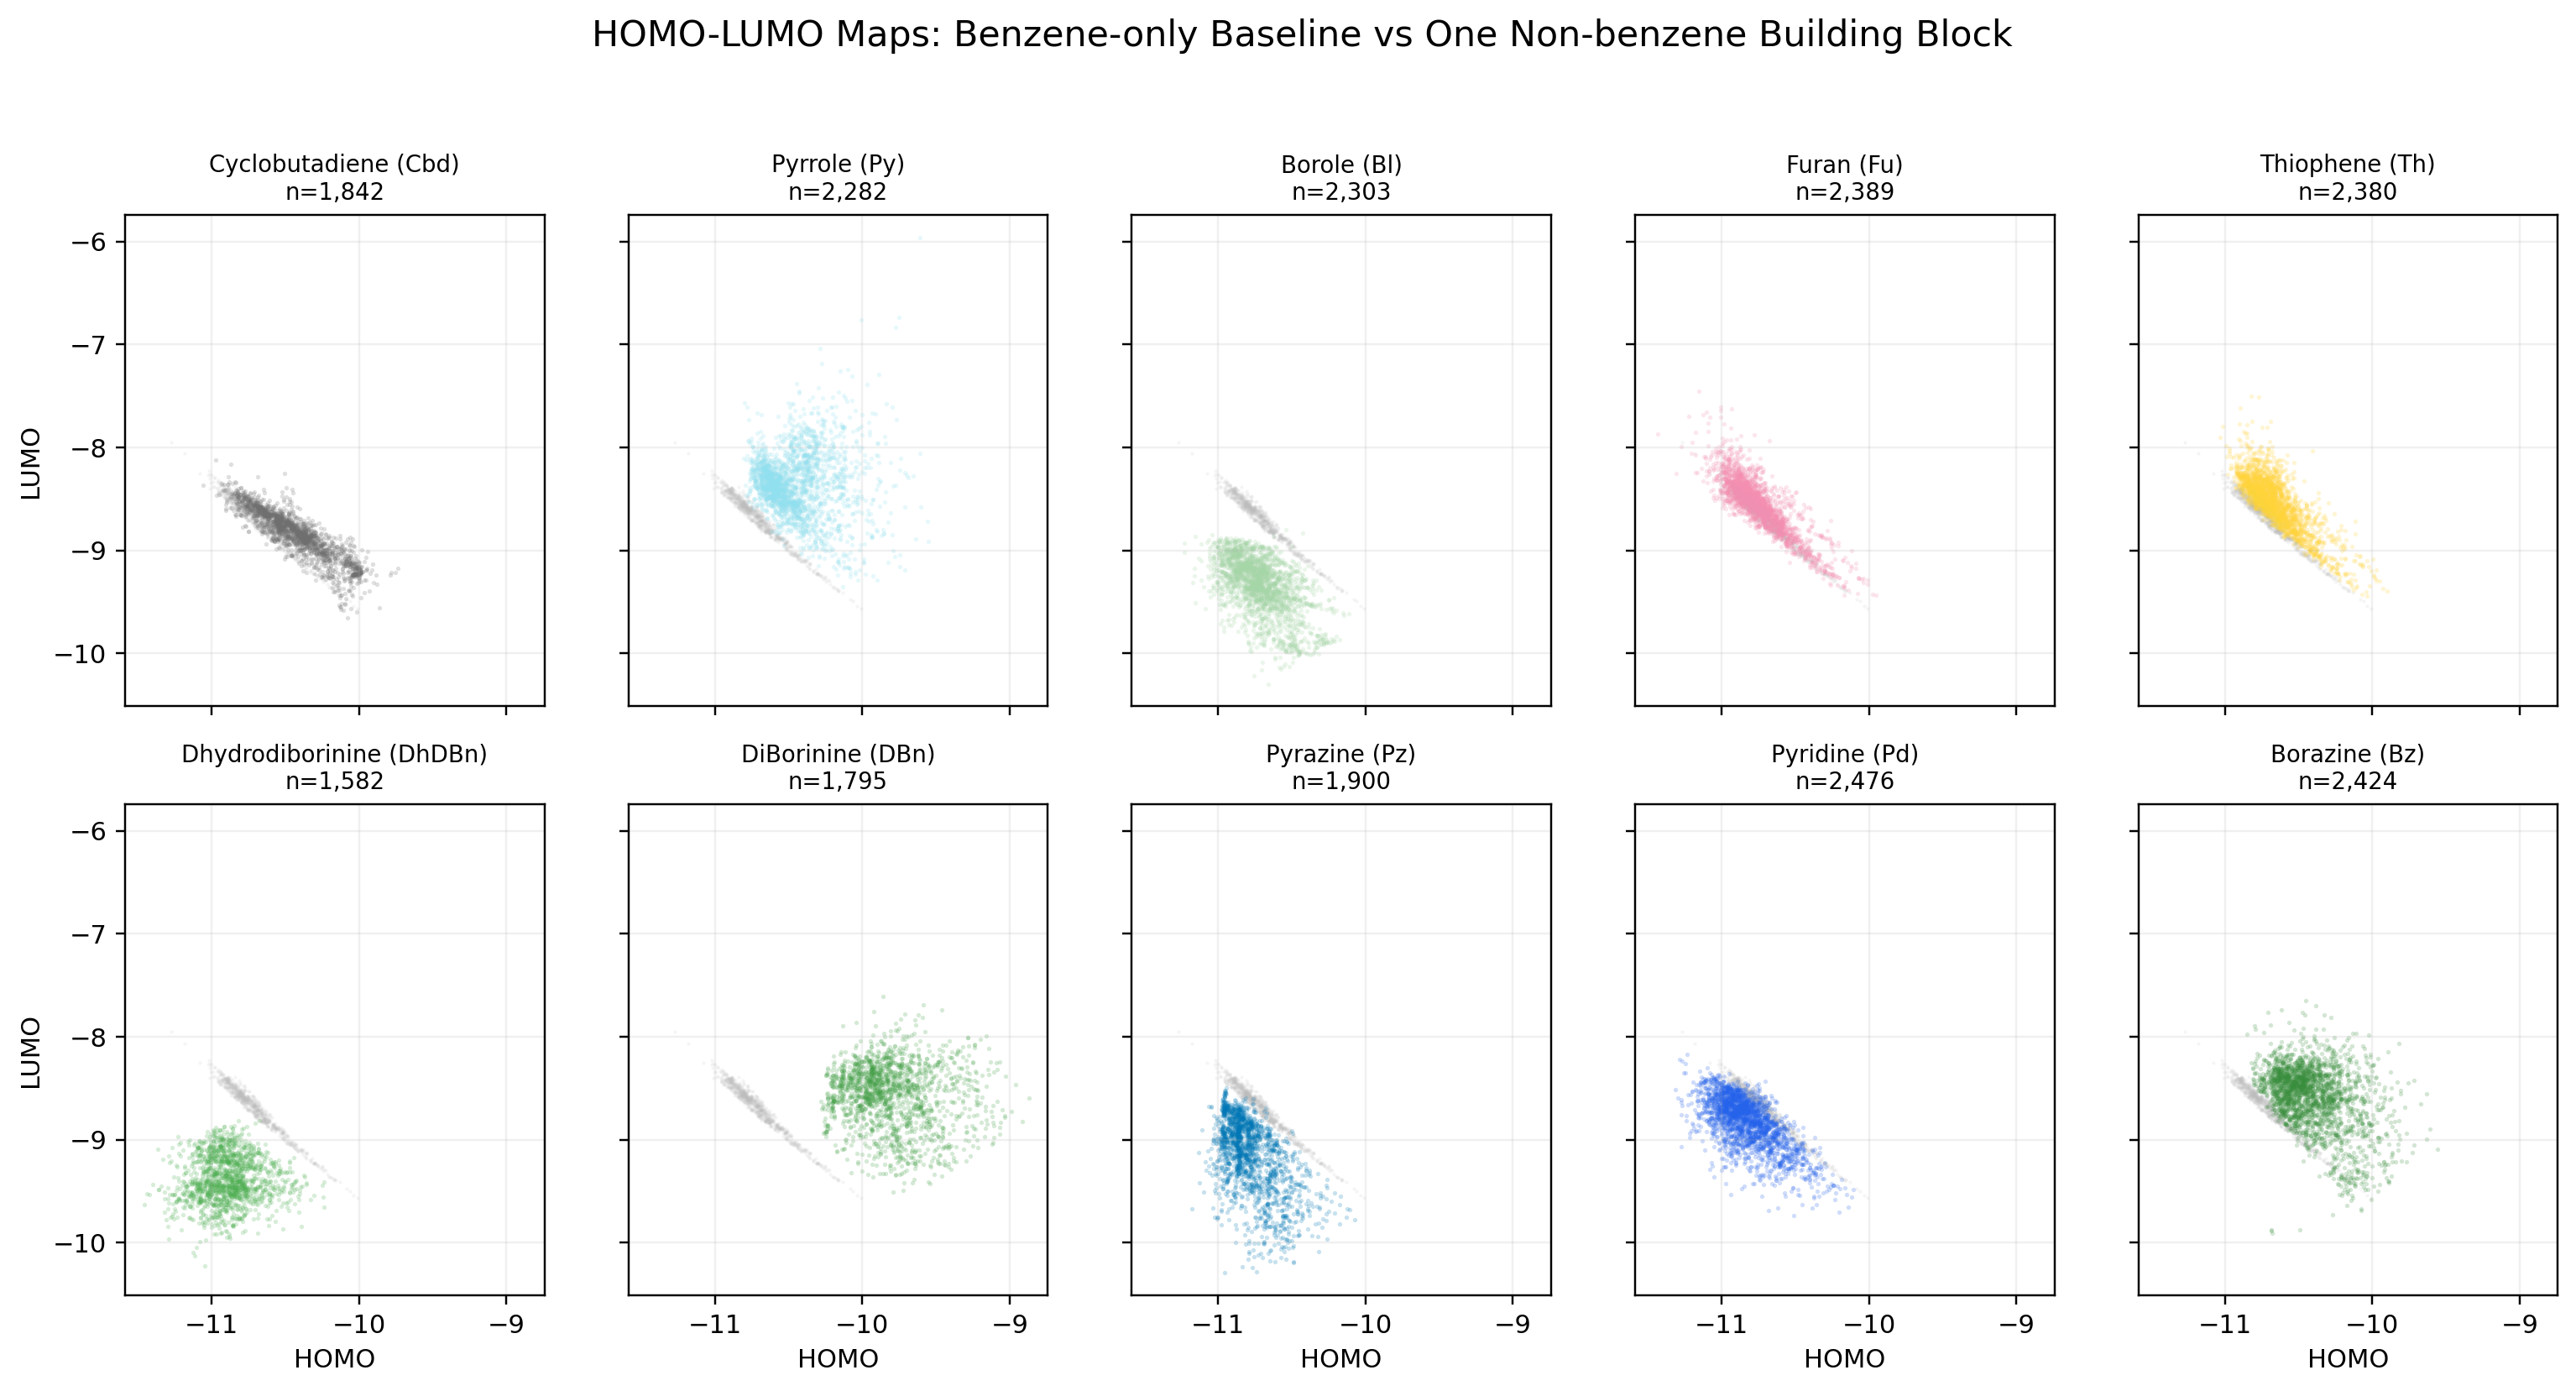

In [20]:
show_image('figure9a_homo_lumo_single_ring_types.png', width=16)

### Interpretation

The broad comparison mirrors the article's conclusion: different ring identities do not simply scatter randomly across the same property space. Borole (Bl) and Dhydrodiborinine (DhDBn) shift strongly toward lower LUMO values, while Furan (Fu) and Thiophene (Th) remain closer to the Benzene (Bn)-only baseline band. Nitrogen-containing rings broaden the accessible HOMO-LUMO region.

In [21]:
scatter_summary = pd.read_csv(TABLE_DIR / 'figure9a_single_ring_scatter_summary.csv')
scatter_summary = scatter_summary.assign(ring_label=scatter_summary['ring_type'].map(RING_LABELS))
scatter_summary[['ring_label', 'single_non_benzene_type_molecules', 'mean_homo', 'mean_lumo', 'mean_gap', 'mean_nfod']].round(3)


,ring_label,single_non_benzene_type_molecules,mean_homo,mean_lumo,mean_gap,mean_nfod
0,Cyclobutadiene (Cbd),1842,-10.421,-8.847,1.573,1.010
1,Pyrrole (Py),2282,-10.441,-8.356,2.085,0.644
2,Borole (Bl),2303,-10.717,-9.341,1.376,1.164
3,Furan (Fu),2389,-10.745,-8.554,2.190,0.600
4,Thiophene (Th),2380,-10.658,-8.536,2.122,0.661
5,Dhydrodiborinine (DhDBn),1582,-10.891,-9.381,1.510,1.193
6,DiBorinine (DBn),1795,-9.808,-8.568,1.240,1.389
7,Pyrazine (Pz),1900,-10.783,-9.155,1.629,1.178
8,Pyridine (Pd),2476,-10.829,-8.829,2.001,0.816
9,Borazine (Bz),2424,-10.408,-8.586,1.822,0.865


## Article Figure 9B-Style View: Ring-Type Prevalence Across Property Ranges

This plot follows the article's stacked-histogram logic. For each electronic property, molecules are binned across the property range (after trimming the 1st and 99th percentiles). Each bar shows the fraction of non-benzene building blocks in that bin.

This answers a slightly different question than the scatter plots: instead of asking where a ring type lies in HOMO-LUMO space, it asks which ring types are enriched at low or high values of each property.

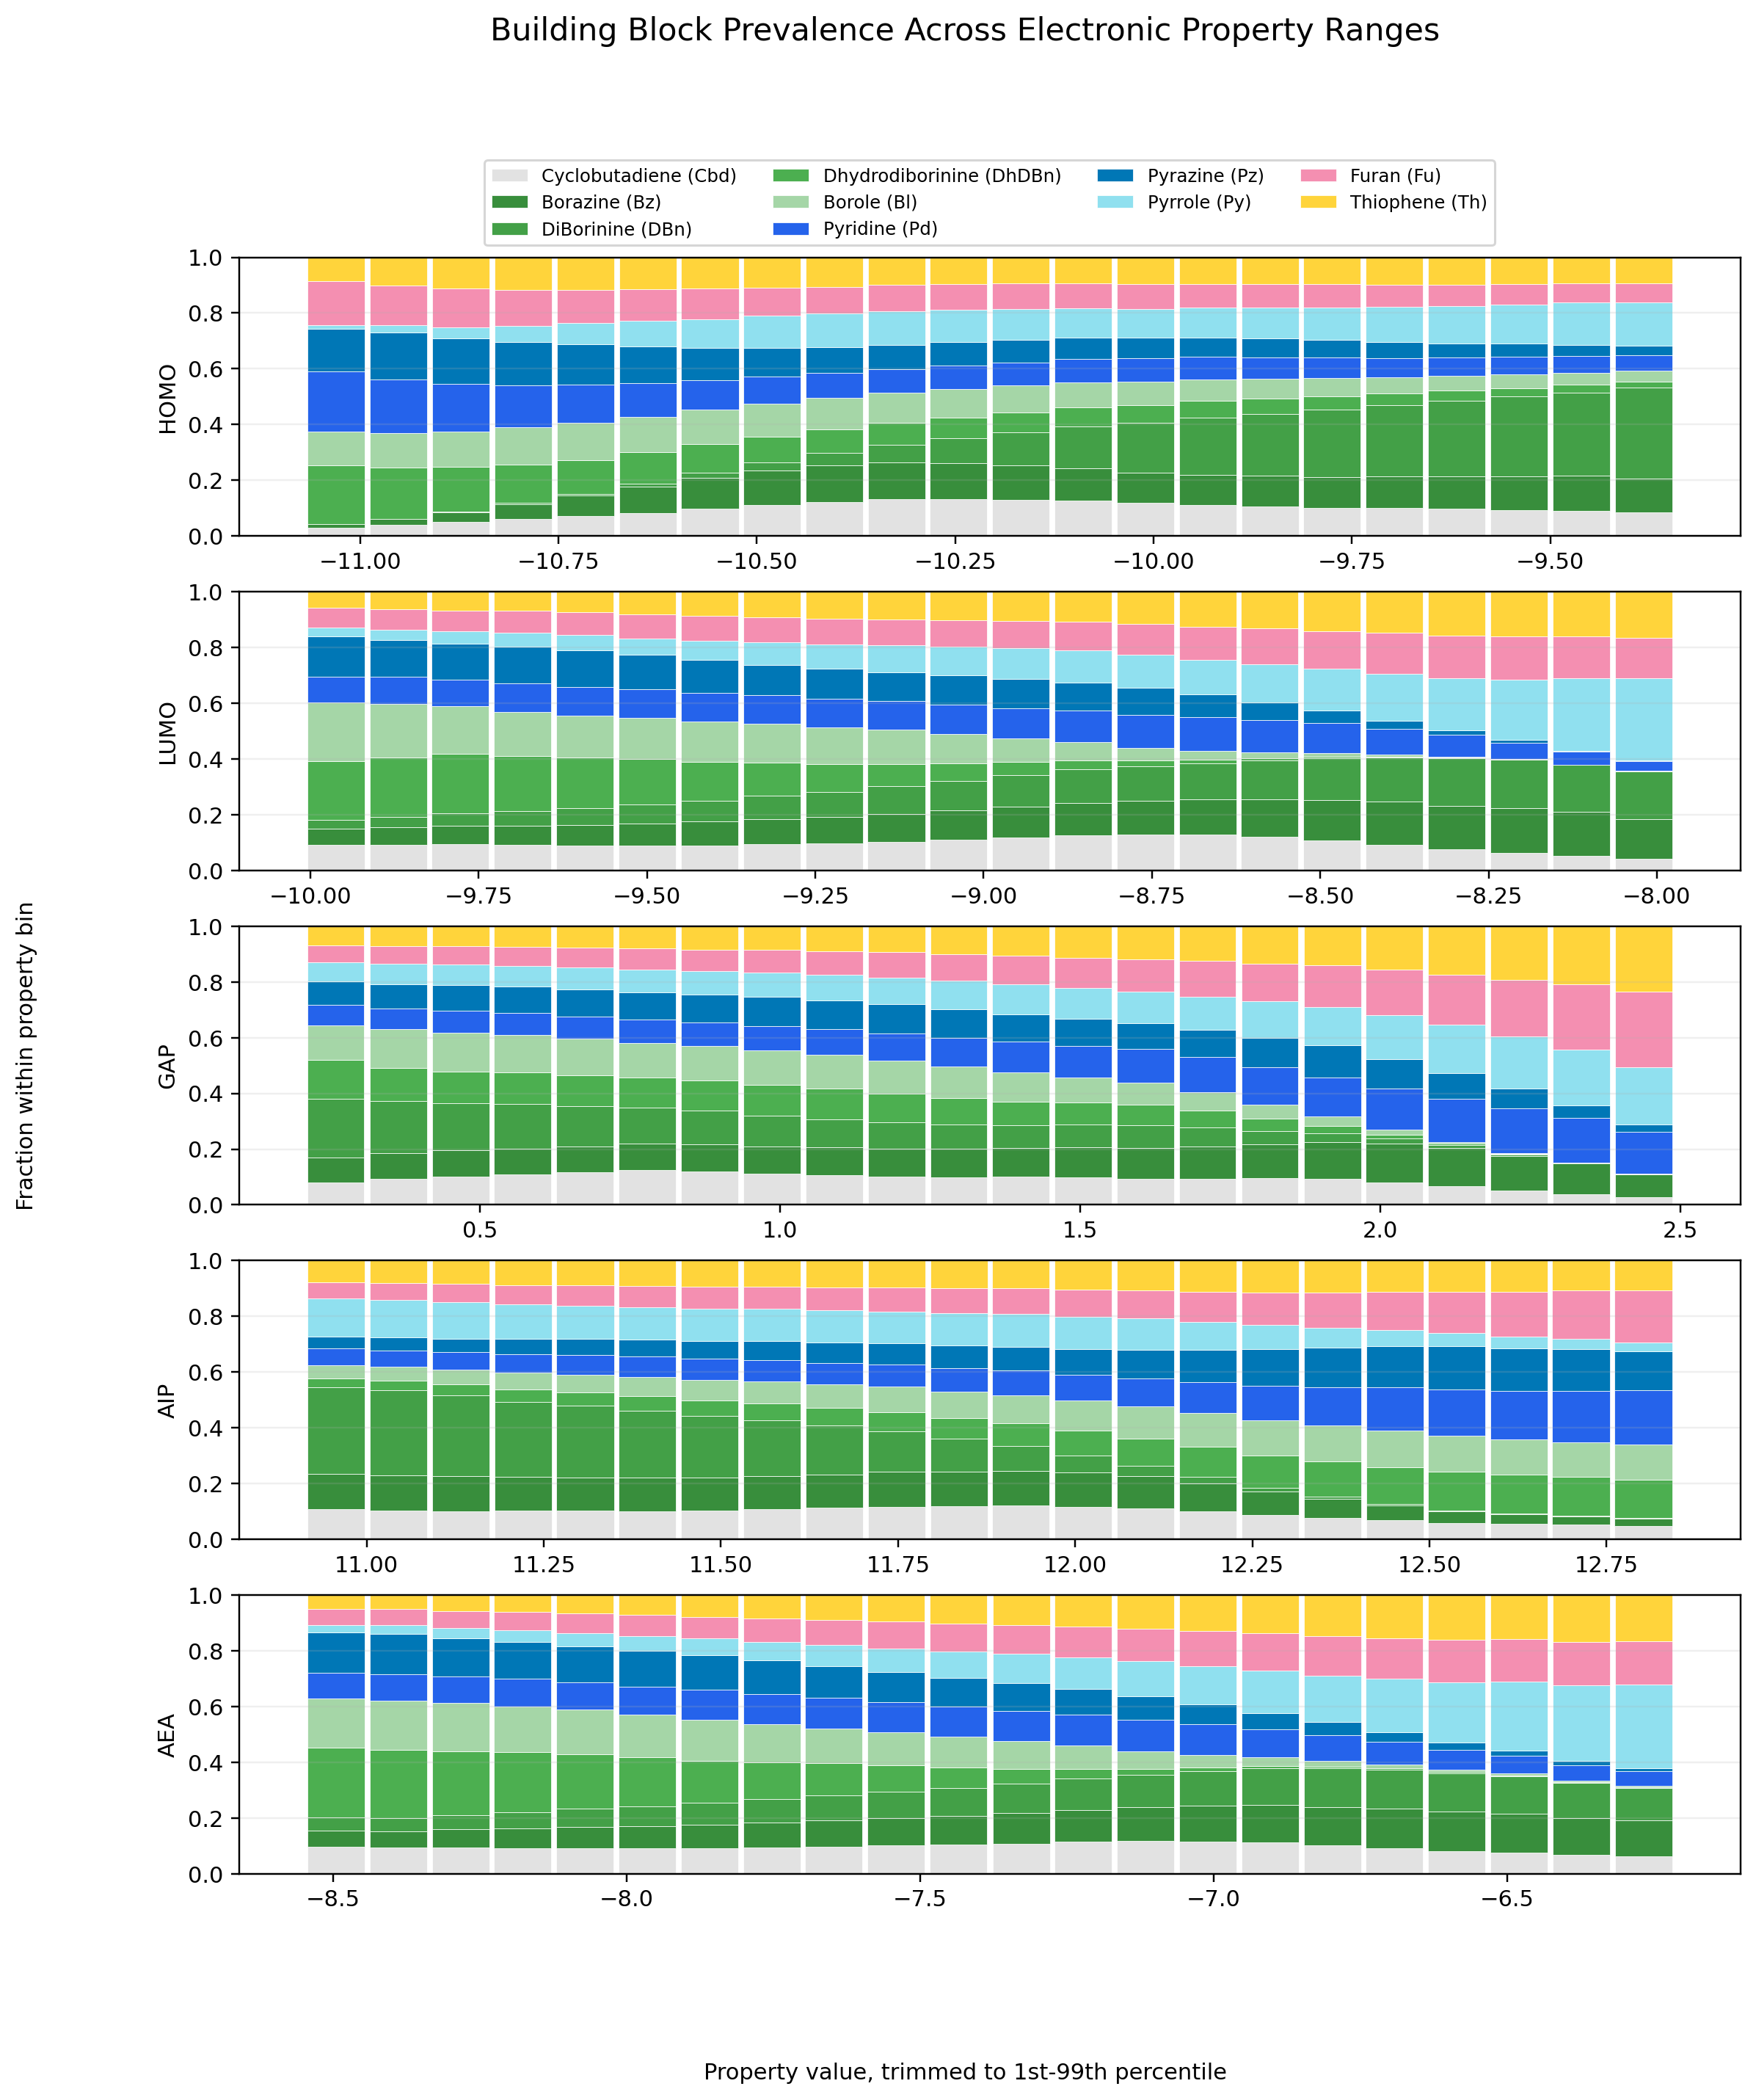

In [23]:
show_image('figure9b_ring_type_stacked_property_histograms.png', width=16)

## Indexed Variant Extension

The article-level ring labels capture the general ring type. The indexed representation enriches this description by encoding heteroatom positions, for example Pd [N:1], Pd [N:4], and Pz [N:1,4]. The following figure reproduces the Figure 9B-style histogram using the indexed variants to provide additional structural detail.

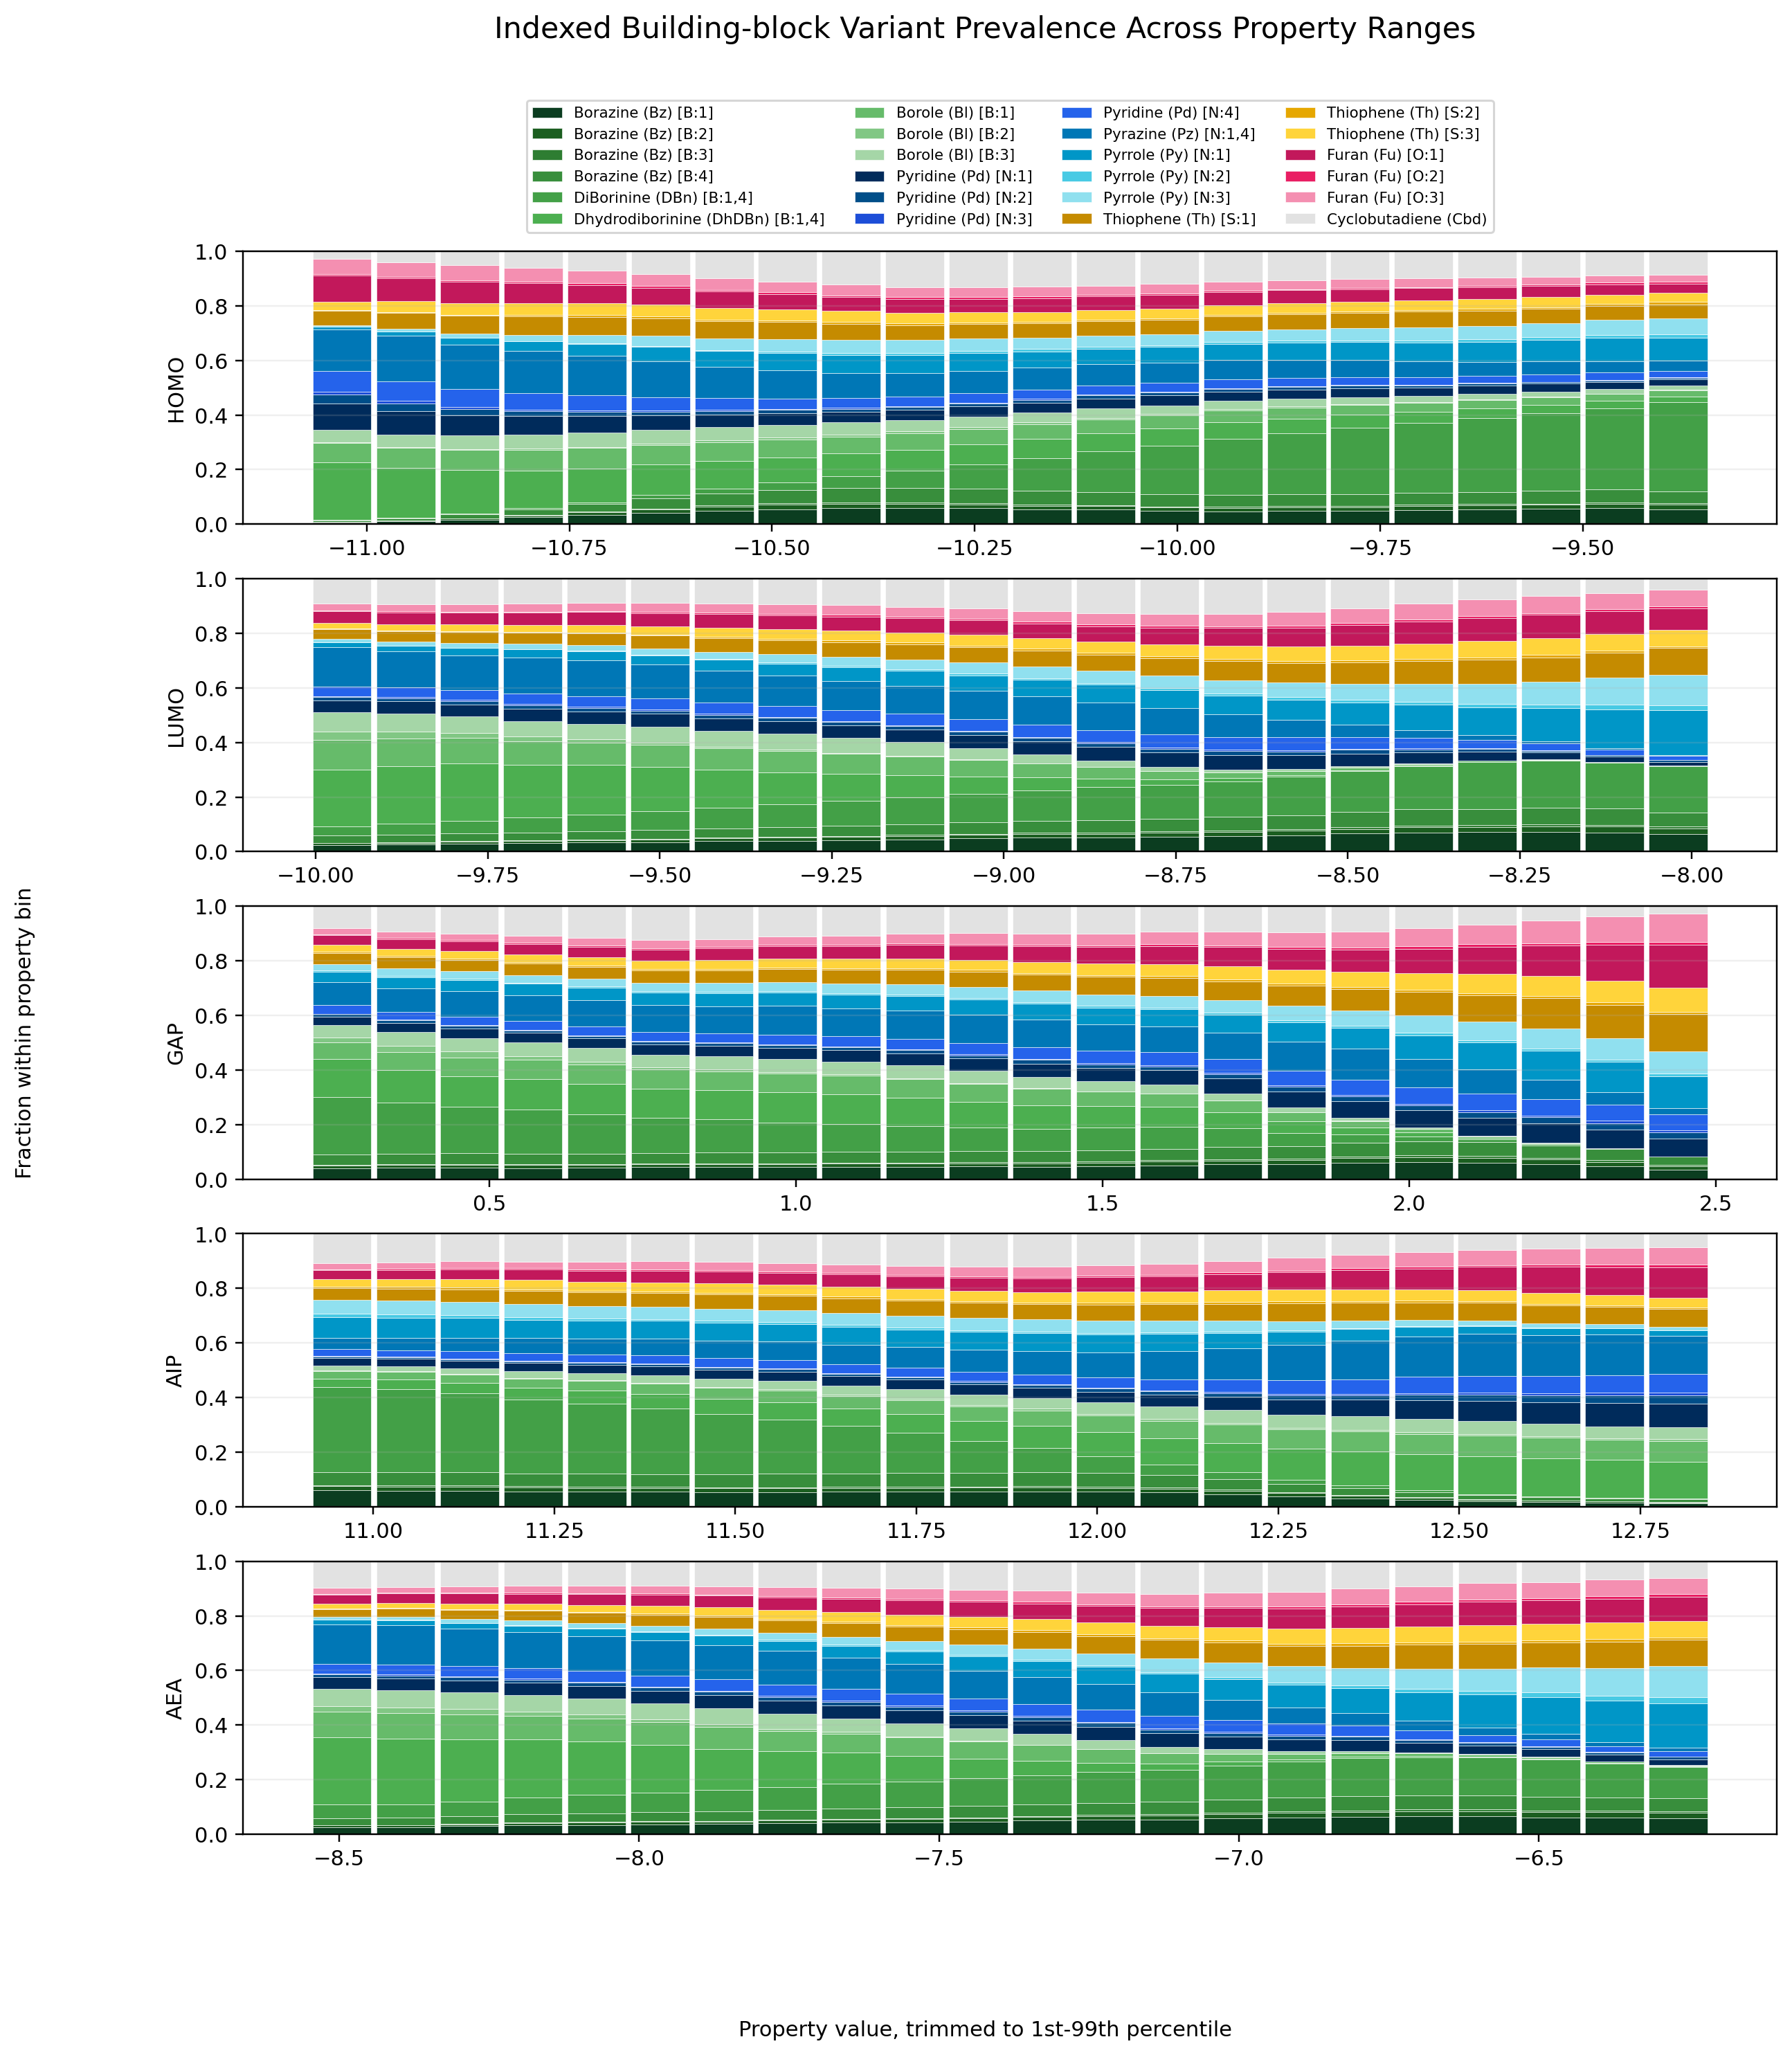

In [24]:
show_image('figure9_like_indexed_variant_stacked_property_histograms.png', width=17)

### Indexed Variant Counts and Mean Properties

This table shows the most common indexed variants and their average electronic properties. One important observation is that Pyrazine (Pz) is almost always `Pz [N:1,4]` in this dataset, so Pyrazine (Pz) has little index diversity. The richer index variation appears for Pyridine (Pd), Pyrrole (Py), Furan (Fu), Thiophene (Th), Borole (Bl), and Borazine (Bz).

In [25]:
variant_summary = pd.read_csv(TABLE_DIR / 'indexed_ring_variant_summary.csv')
variant_summary[['variant_label', 'molecules', 'mean_homo', 'mean_lumo', 'mean_gap', 'mean_aip', 'mean_aea', 'mean_nfod']].round(3)

,variant_label,molecules,mean_homo,mean_lumo,mean_gap,mean_aip,mean_aea,mean_nfod
0,Cyclobutadiene (Cbd),178355,-10.247,-9.077,1.170,11.902,-7.448,1.501
1,Pyrrole (Py) [N:1],110432,-10.216,-8.887,1.329,11.878,-7.228,1.301
2,Pyrrole (Py) [N:3],78765,-10.219,-8.878,1.342,11.875,-7.221,1.289
3,Pyrrole (Py) [N:2],11832,-10.077,-8.780,1.297,11.770,-7.115,1.317
4,Pyrrole (Py) [N:4],1,-9.211,-8.422,0.789,10.869,-6.889,1.563
5,Borole (Bl) [B:1],110582,-10.399,-9.313,1.086,12.043,-7.648,1.592
6,Borole (Bl) [B:3],77931,-10.395,-9.334,1.061,12.033,-7.669,1.611
7,Borole (Bl) [B:2],11545,-10.345,-9.632,0.714,12.015,-7.918,2.035
8,Borole (Bl) [B:4],1,-9.671,-9.211,0.460,11.201,-7.800,2.784
9,Furan (Fu) [O:1],109013,-10.377,-9.007,1.370,12.052,-7.341,1.264


## Figure 9A-Style Indexed Variant Examples

The following panels split selected ring families by indexed heteroatom position. These figures are useful when discussing whether the effect is general to a ring family or depends on the heteroatom index within that ring.

In [ ]:
for filename in [
    'figure9_like_indexed_pyridine_homo_lumo.png',
    'figure9_like_indexed_borole_homo_lumo.png',
    'figure9_like_indexed_borinine_homo_lumo.png',
]:
    show_image(filename, width=13)

## Heteroatom-Level Comparison, Similar to Article Figure 7

The article also analyzes trends by heteroatom type. This plot aggregates over ring identity and focuses on B, N, O, and S enrichment across property bins. The values are normalized against each heteroatom's global prevalence, so the plot emphasizes relative enrichment rather than raw abundance.

In [ ]:
show_image('figure7_like_heteroatom_enrichment_property_histograms.png', width=16)

## Antiaromatic Ring Count, Similar to Article Figure 8

The article compares electronic-property distributions by the number of antiaromatic rings. Here, antiaromatic rings are counted as Cyclobutadiene (Cbd), Borole (Bl), and Dhydrodiborinine (DhDBn). This provides a higher-level structural trend that complements the specific ring identity analysis.

In [ ]:
show_image('figure8_like_antiaromatic_property_distributions.png', width=16)

## Additional Diagnostic 1: Ring Presence and Property Shifts

This heatmap summarizes mean property shifts for molecules containing each ring type. Values are z-scores relative to the full dataset mean and standard deviation. It is a compact way to compare which ring families are associated with low LUMO, low gap, high NFOD, or changes in heteroatom density.

In [ ]:
show_image('ring_property_mean_zscore_heatmap.png', width=12)

## Additional Diagnostic 2: Ring Count Histograms

These histograms show how many times each non-benzene ring type appears per molecule. This helps distinguish ring types that mainly appear once from those that frequently occur multiple times in the same molecule.

In [ ]:
show_image('ring_type_count_histograms.png', width=15)

## Additional Diagnostic 3: Ring Co-occurrence

The article's Figure 9A isolates molecules with Benzene (Bn) plus one other ring type. In the full dataset, many molecules mix multiple heterocycles. This co-occurrence heatmap shows which non-benzene ring types tend to appear together.

In [ ]:
show_image('ring_type_cooccurrence_heatmap.png', width=10)

## Main Takeaways

1. The generated figures reproduce the article's main comparison style: ring identity strongly structures the HOMO-LUMO space and the property histograms.
2. Borole (Bl) and Dhydrodiborinine (DhDBn) are associated with lower LUMO/lower gap and higher NFOD.
3. Furan (Fu) and Thiophene (Th) remain closer to the Benzene (Bn)-only baseline than the B- and N-containing heterocycles.
4. The indexed-variant analysis adds resolution beyond the article-style ring labels, especially for Pyridine (Pd), Pyrrole (Py), Furan (Fu), Thiophene (Th), Borole (Bl), and Borazine (Bz).
5. Pyrazine (Pz) is essentially represented by one dominant indexed variant, `Pz [N:1,4]`, so it does not split meaningfully by index in this dataset.

## Suggested Follow-Up Analyses

- Compare single-ring-family molecules versus mixed-heterocycle molecules to separate clean ring effects from interaction effects.
- Add 2D density contours to HOMO-LUMO plots to quantify the dense regions more clearly.
- Build pairwise ring-interaction tables: expected property shift from ring A plus ring B versus observed shift when both appear together.
- Connect this exploratory analysis to the RF ablation experiments by checking whether the most visually important ring families are also the most predictive features.